In [47]:
import adapters                         # registers adapter hooks
from adapters import AutoAdapterModel   # modern import path
from transformers import AutoConfig, AutoProcessor
import torch.nn.functional as F


In [48]:
# Cell 0: Environment setup (run once per kernel)
!pip -q install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu
!pip -q install transformers peft accelerate datasets scikit-learn einops matplotlib seaborn adapter-transformers

import os, random, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Device: prefer Apple Metal (mps) on M3 Pro, else CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device


device(type='mps')

In [49]:
# Cell 1: Data loading & preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 🔧 CHANGE ME: Path to your CSV
CSV_PATH = "df_segment2.csv"  # e.g., "/Users/you/data/df_segment2.csv"

df = pd.read_csv(CSV_PATH, header=None)  # assuming no header
assert df.shape[1] == 601, f"Expected 601 columns, got {df.shape[1]}"

X = df.iloc[:, :-1].astype(np.float32).values  # (N, 600)
y = df.iloc[:, -1].astype(int).values          # (N,)

# --- Normalization options ---
USE_GLOBAL_ZSCORE = False   # default required: row-wise; toggle to True for ablation

if USE_GLOBAL_ZSCORE:
    scaler = StandardScaler(with_mean=True, with_std=True)
    X = scaler.fit_transform(X)
else:
    # Row-wise z-score: (x - mean_row) / std_row, safe for zero-std
    row_mean = X.mean(axis=1, keepdims=True)
    row_std = X.std(axis=1, keepdims=True)
    row_std[row_std == 0] = 1.0
    X = (X - row_mean) / row_std

# Train/Val/Test splits (stratified)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

X_train.shape, X_val.shape, X_test.shape, y_train.mean(), y_val.mean(), y_test.mean()


((45797, 600),
 (9814, 600),
 (9814, 600),
 np.float64(0.49839509138153154),
 np.float64(0.49836967597309967),
 np.float64(0.4984715712247809))

In [50]:
# Cell 2: Torch Dataset & DataLoaders with interpolation to 16000 samples
from torch.utils.data import Dataset, DataLoader

TARGET_LEN = 16000  # 1D length for speech models

def linear_interpolate_1d(x: np.ndarray, target_len: int) -> np.ndarray:
    # x: (L,) -> (target_len,)
    src_len = x.shape[0]
    if src_len == target_len:
        return x
    xp = np.linspace(0, 1, num=src_len, dtype=np.float32)
    fp = x.astype(np.float32)
    xnew = np.linspace(0, 1, num=target_len, dtype=np.float32)
    return np.interp(xnew, xp, fp).astype(np.float32)

class ECGDataset(Dataset):
    def __init__(self, X, y, resample_to=TARGET_LEN):
        self.X = X
        self.y = y
        self.resample_to = resample_to

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        wave = self.X[idx]
        wave = linear_interpolate_1d(wave, self.resample_to)  # (target_len,)
        return torch.from_numpy(wave), torch.tensor(self.y[idx], dtype=torch.long)

BATCH_SIZE = 64  # adjust if memory-limited

train_ds = ECGDataset(X_train, y_train)
val_ds   = ECGDataset(X_val, y_val)
test_ds  = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

len(train_ds), len(val_ds), len(test_ds)


(45797, 9814, 9814)

In [97]:
# Cell 3 — Metrics & evaluation helpers (updated)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
import numpy as np

def compute_metrics(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
    except Exception:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_pred)

    return {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc, "cm": cm}


In [98]:
# Cell 4 — Training & evaluation (dict/tuple compatible)
import torch
from torch.optim import AdamW
from copy import deepcopy

def _move_to_device(x, device):
    if isinstance(x, torch.Tensor):
        return x.to(device)
    if isinstance(x, dict):
        return {k: _move_to_device(v, device) for k, v in x.items() if v is not None}
    if isinstance(x, (list, tuple)):
        return type(x)(_move_to_device(v, device) for v in x)
    return x

def _batch_to_inputs_and_labels(batch, device):
    """
    Supports:
      1) dict: {"input_values": BxT, "attention_mask": BxT?, "labels": B}
      2) tuple: (waves, labels) -> converts to {"input_values": waves}, labels
      3) tuple: ({"input_values":..., "attention_mask":...}, labels)
    Returns: (inputs_dict, labels_tensor)
    """
    if isinstance(batch, dict):
        labels = batch["labels"]
        inputs = {k: v for k, v in batch.items() if k != "labels"}
        return _move_to_device(inputs, device), labels.to(device).float()

    if isinstance(batch, (list, tuple)) and len(batch) == 2:
        a, b = batch
        if isinstance(a, dict):  # ({inputs...}, labels)
            return _move_to_device(a, device), b.to(device).float()
        else:                     # (waves, labels)
            inputs = {"input_values": a}
            return _move_to_device(inputs, device), b.to(device).float()

    raise ValueError("Unexpected batch format from DataLoader")

def train_model(model, processor, train_loader, val_loader, device,
                lr=1e-4, epochs=5, weight_decay=1e-4, patience=2):
    model = model.to(device)
    optimizer = AdamW((p for p in model.parameters() if p.requires_grad),
                      lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for batch in train_loader:
            inputs, labels = _batch_to_inputs_and_labels(batch, device)
            optimizer.zero_grad(set_to_none=True)
            out = model(**inputs, labels=labels)
            loss = out.loss
            loss.backward()
            optimizer.step()
            running += loss.item()

        # validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                inputs, labels = _batch_to_inputs_and_labels(batch, device)
                out = model(**inputs, labels=labels)
                val_loss += out.loss.item()
        val_loss /= max(1, len(val_loader))

        # early stopping on val loss
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    return model

def evaluate(model, processor, data_loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in data_loader:
            inputs, labels = _batch_to_inputs_and_labels(batch, device)
            out = model(**inputs)  # no labels -> no loss
            logits = out.logits if hasattr(out, "logits") else out
            probs = torch.sigmoid(logits.squeeze(-1))
            all_probs.append(probs.detach().cpu())
            all_labels.append(labels.detach().cpu())

    y_prob = torch.cat(all_probs, dim=0).numpy()
    y_true = torch.cat(all_labels, dim=0).numpy().astype(int)
    return compute_metrics(y_true, y_prob)


In [99]:
import torch
import torch.nn.functional as F

TARGET_LEN = 16000  # ~1s at 16k; adjust if you prefer longer context

def zscore_per_row(x: torch.Tensor) -> torch.Tensor:
    # x: (N, L) float32
    mean = x.mean(dim=1, keepdim=True)
    std = x.std(dim=1, unbiased=False, keepdim=True).clamp_min(1e-6)
    return (x - mean) / std

def upsample_to_target_len(x1d: torch.Tensor, target_len: int = TARGET_LEN) -> torch.Tensor:
    # x1d: (L,) -> (1,1,L) for interpolate, then squeeze back to (target_len,)
    x = x1d.view(1, 1, -1)
    y = F.interpolate(x, size=target_len, mode="linear", align_corners=False)
    return y.view(-1)

def ecg_to_wav2vec_inputs(batch_signals, batch_labels, processor):
    """
    batch_signals: list[Tensor(L=600) or np.ndarray], batch_labels: list[int 0/1]
    Returns dict with input_values (B, T) float32 and labels (B,) float32
    """
    # to tensor (B, L)
    B = len(batch_signals)
    x = torch.stack([torch.as_tensor(s, dtype=torch.float32) for s in batch_signals], dim=0)
    x = zscore_per_row(x)
    x = torch.stack([upsample_to_target_len(row) for row in x], dim=0)  # (B, TARGET_LEN)

    # processor builds attention_mask & pads if needed
    proc = processor(x.numpy(), sampling_rate=16000, return_tensors="pt", padding=True)
    labels = torch.as_tensor(batch_labels, dtype=torch.float32)
    return {"input_values": proc["input_values"], "attention_mask": proc.get("attention_mask", None), "labels": labels}


In [100]:
def collate_fn(batch):
    signals, labels = zip(*batch)
    return ecg_to_wav2vec_inputs(signals, labels, processor_wav)


In [101]:
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_fn)


In [64]:
# Cell 6 — Wav2Vec2 + Adapter-style Fine-Tuning (with extractor mask pooling)

from transformers import AutoProcessor, Wav2Vec2Model
import torch
import torch.nn as nn
import torch.nn.functional as F

WAV_MODEL = "facebook/wav2vec2-base"

# Processor for waveform -> model inputs
try:
    processor_wav
except NameError:
    processor_wav = AutoProcessor.from_pretrained(
        WAV_MODEL, do_normalize=True, return_attention_mask=True
    )

# Load pretrained encoder and freeze it (adapter-style training)
encoder = Wav2Vec2Model.from_pretrained(WAV_MODEL)
for p in encoder.parameters():
    p.requires_grad = False

class Wav2Vec2AdapterClassifier(nn.Module):
    """
    Adapter-style classifier: freeze encoder, train a small bottleneck MLP on pooled features.
    Uses the downsampled extractor mask to pool correctly.
    Expects dict batches: input_values (B,T), attention_mask (B,T), labels (B,)
    """
    def __init__(self, base_encoder: Wav2Vec2Model, hidden=256, p_drop=0.1):
        super().__init__()
        self.encoder = base_encoder
        h = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(h, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, 1),
        )

    def forward(self, input_values, attention_mask=None, labels=None):
        outputs = self.encoder(
            input_values=input_values,
            attention_mask=attention_mask,
            return_dict=True
        )
        hidden = outputs.last_hidden_state  # (B, T', H)

        # Use encoder's downsampled mask if available; otherwise downsample input mask
        feat_mask = getattr(outputs, "extractor_attention_mask", None)  # (B, T') or None
        if feat_mask is None and attention_mask is not None:
            T = hidden.size(1)
            feat_mask = F.interpolate(
                attention_mask[:, None, :].float(), size=T, mode="nearest"
            ).squeeze(1)

        # Mask-aware mean pooling
        if feat_mask is not None:
            mask = feat_mask.unsqueeze(-1).type_as(hidden)  # (B, T', 1)
            summed = (hidden * mask).sum(dim=1)             # (B, H)
            denom = mask.sum(dim=1).clamp_min(1e-6)         # (B, 1)
            pooled = summed / denom
        else:
            pooled = hidden.mean(dim=1)

        logits = self.head(pooled)                          # (B, 1)

        if labels is not None:
            labels = labels.unsqueeze(1).to(logits.dtype)
            loss = F.binary_cross_entropy_with_logits(logits, labels)
            return type("Output", (), {"loss": loss, "logits": logits})
        return type("Output", (), {"logits": logits})

# Instantiate the adapter-style model
model = Wav2Vec2AdapterClassifier(encoder).to(device)

# Report PEFT-ness
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params (Adapter Head Only): {trainable:,} || all params: {total:,} || trainable%: {100*trainable/total:.4f}")


Trainable params (Adapter Head Only): 197,121 || all params: 94,568,833 || trainable%: 0.2084


In [65]:
# (a) Wav2Vec2 + Adapter-style head
wav_adapters = train_model(model=model, processor=processor_wav,
                           train_loader=train_loader, val_loader=val_loader, device=device,
                           lr=1e-4, epochs=5, weight_decay=1e-4, patience=2)
wav_adapters_val = evaluate(wav_adapters, processor_wav, val_loader, device)
wav_adapters_test = evaluate(wav_adapters, processor_wav, test_loader, device)
print("Wav2Vec2 Adapters →", wav_adapters_val, wav_adapters_test)

Wav2Vec2 Adapters → {'acc': 0.554004483391074, 'precision': 0.543886612021858, 'recall': 0.6511960744224085, 'f1': 0.5927235507583511, 'auc': 0.5794878005355257, 'cm': array([[2252, 2671],
       [1706, 3185]])} {'acc': 0.5676584471163644, 'precision': 0.5559193520592797, 'recall': 0.6594439901880621, 'f1': 0.6032725572697523, 'auc': 0.5953395039476005, 'cm': array([[2345, 2577],
       [1666, 3226]])}


In [68]:
# Cell 7 — Wav2Vec2 + LoRA (PEFT) for binary ECG classification (safe wrapper)

from transformers import AutoProcessor, Wav2Vec2ForSequenceClassification, AutoConfig
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F
import types

WAV_MODEL = "facebook/wav2vec2-base"

# 1) Config: single logit; we'll compute BCE-with-logits ourselves
config = AutoConfig.from_pretrained(
    WAV_MODEL,
    num_labels=1,
    problem_type="single_label_classification",
)

# 2) Processor (reuse if already defined)
try:
    processor_wav
except NameError:
    processor_wav = AutoProcessor.from_pretrained(
        WAV_MODEL, do_normalize=True, return_attention_mask=True
    )

# 3) Base model
base = Wav2Vec2ForSequenceClassification.from_pretrained(
    WAV_MODEL, config=config
).to(device)

# 4) Patch: prevent PEFT from calling get_input_embeddings() (audio models don't expose them)
def _noop_enable_input_require_grads(self):
    return
base.enable_input_require_grads = _noop_enable_input_require_grads.__get__(base, type(base))

# 5) LoRA over attention projections
lora_cfg = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.10,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
)

model = get_peft_model(base, lora_cfg).to(device)
model.print_trainable_parameters()

# 6) Safe BCE-with-logits wrapper (avoid recursion by calling the ORIGINAL forward)
if not hasattr(model, "_orig_forward"):
    model._orig_forward = model.forward  # save original HF forward once

def forward_with_labels(self, **kwargs):
    labels = kwargs.pop("labels", None)
    out = self._orig_forward(**kwargs)         # call original forward (no recursion)
    logits = out.logits if hasattr(out, "logits") else out
    if labels is not None:
        labels = labels.unsqueeze(1).to(logits.dtype)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        return type("Output", (), {"loss": loss, "logits": logits})
    return type("Output", (), {"logits": logits})

model.forward = types.MethodType(forward_with_labels, model)


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 589,824 || all params: 95,158,657 || trainable%: 0.6198


In [69]:
#(b)
wav_lora = train_model(model=model, processor=processor_wav,
                       train_loader=train_loader, val_loader=val_loader, device=device,
                       lr=5e-5, epochs=5, weight_decay=1e-4, patience=2)
wav_lora_val = evaluate(wav_lora, processor_wav, val_loader, device)
wav_lora_test = evaluate(wav_lora, processor_wav, test_loader, device)
print("Wav2Vec2 LoRA →", wav_lora_val, wav_lora_test)

Wav2Vec2 LoRA → {'acc': 0.5745873242306908, 'precision': 0.5701135918527223, 'recall': 0.5951748108771212, 'f1': 0.5823747124137241, 'auc': 0.6070021367289753, 'cm': array([[2728, 2195],
       [1980, 2911]])} {'acc': 0.5835541063786428, 'precision': 0.5797187561893444, 'recall': 0.598323793949305, 'f1': 0.5888743587164269, 'auc': 0.6195536302542061, 'cm': array([[2800, 2122],
       [1965, 2927]])}


In [71]:
# Cell 8 — HuBERT + Adapter-Style Fine-Tuning (with extractor mask pooling)

from transformers import AutoFeatureExtractor, HubertModel
import torch
import torch.nn as nn
import torch.nn.functional as F

HUBERT_MODEL = "facebook/hubert-base-ls960"

# Use feature extractor (HuBERT has no tokenizer)
try:
    feature_extractor_hubert
except NameError:
    feature_extractor_hubert = AutoFeatureExtractor.from_pretrained(
        HUBERT_MODEL, do_normalize=True, return_attention_mask=True
    )

# Load pretrained HuBERT encoder and freeze all layers (adapter-style training)
encoder_hubert = HubertModel.from_pretrained(HUBERT_MODEL)
for p in encoder_hubert.parameters():
    p.requires_grad = False

# Adapter-style classifier using extractor (downsampled) mask for correct pooling
class HubertAdapterClassifier(nn.Module):
    def __init__(self, base_encoder: HubertModel, hidden=256, p_drop=0.1):
        super().__init__()
        self.encoder = base_encoder
        h = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(h, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, 1),
        )

    def forward(self, input_values, attention_mask=None, labels=None):
        outputs = self.encoder(
            input_values=input_values,
            attention_mask=attention_mask,
            return_dict=True
        )
        hidden = outputs.last_hidden_state  # (B, T', H)

        # Prefer the extractor (downsampled) mask; otherwise downsample input mask to T'
        feat_mask = getattr(outputs, "extractor_attention_mask", None)  # (B, T') or None
        if feat_mask is None and attention_mask is not None:
            Tprime = hidden.size(1)
            feat_mask = F.interpolate(
                attention_mask[:, None, :].float(), size=Tprime, mode="nearest"
            ).squeeze(1)  # (B, T')

        # Mask-aware mean pooling
        if feat_mask is not None:
            mask = feat_mask.unsqueeze(-1).type_as(hidden)  # (B, T', 1)
            summed = (hidden * mask).sum(dim=1)             # (B, H)
            denom = mask.sum(dim=1).clamp_min(1e-6)         # (B, 1)
            pooled = summed / denom
        else:
            pooled = hidden.mean(dim=1)

        logits = self.head(pooled)  # (B, 1)

        if labels is not None:
            labels = labels.unsqueeze(1).to(logits.dtype)
            loss = F.binary_cross_entropy_with_logits(logits, labels)
            return type("Output", (), {"loss": loss, "logits": logits})
        return type("Output", (), {"logits": logits})

# Initialize model
model_hubert_adapter = HubertAdapterClassifier(encoder_hubert).to(device)

# Parameter summary
trainable = sum(p.numel() for p in model_hubert_adapter.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_hubert_adapter.parameters())
print(f"Trainable params (HuBERT + Adapter Head): {trainable:,} || all params: {total:,} || trainable%: {100*trainable/total:.4f}")


Trainable params (HuBERT + Adapter Head): 197,121 || all params: 94,568,833 || trainable%: 0.2084


In [73]:
# (c) HuBERT + Adapter-style head  (from Cell 8)
# Your Cell 8 defines: model_hubert_adapter
hub_adapters = train_model(
    model=model_hubert_adapter, processor=feature_extractor_hubert,
    train_loader=train_loader, val_loader=val_loader, device=device,
    lr=1e-4, epochs=5, weight_decay=1e-4, patience=2
)
hub_adapters_val  = evaluate(hub_adapters, feature_extractor_hubert,  val_loader,  device)
hub_adapters_test = evaluate(hub_adapters, feature_extractor_hubert,  test_loader, device)
print("HuBERT + Adapters →", hub_adapters_val, hub_adapters_test)


HuBERT + Adapters → {'acc': 0.5306704707560628, 'precision': 0.5176514306949089, 'recall': 0.8544264976487426, 'f1': 0.6447084233261339, 'auc': 0.5733512614400803, 'cm': array([[1029, 3894],
       [ 712, 4179]])} {'acc': 0.5348481760749949, 'precision': 0.5202376531748979, 'recall': 0.8591578086672118, 'f1': 0.6480610592860998, 'auc': 0.5886396676127972, 'cm': array([[1046, 3876],
       [ 689, 4203]])}


In [76]:
# Cell 9 — HuBERT + LoRA (PEFT) for binary ECG classification (safe wrapper)

from transformers import AutoFeatureExtractor, HubertForSequenceClassification, AutoConfig
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F
import types

HUBERT_MODEL = "facebook/hubert-base-ls960"

# 1) Config: single logit (we'll compute BCE-with-logits)
hub_config = AutoConfig.from_pretrained(
    HUBERT_MODEL,
    num_labels=1,
    problem_type="single_label_classification",
)

# 2) Feature extractor (HuBERT has no tokenizer)
try:
    feature_extractor_hubert
except NameError:
    feature_extractor_hubert = AutoFeatureExtractor.from_pretrained(
        HUBERT_MODEL, do_normalize=True, return_attention_mask=True
    )

# 3) Base classification model
hub_base = HubertForSequenceClassification.from_pretrained(
    HUBERT_MODEL, config=hub_config
).to(device)

# 4) Patch: prevent PEFT from calling get_input_embeddings() on audio models
def _noop_enable_input_require_grads(self):
    return
hub_base.enable_input_require_grads = _noop_enable_input_require_grads.__get__(hub_base, type(hub_base))

# 5) LoRA on attention projections
hub_lora_cfg = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.10,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
)

hub_model = get_peft_model(hub_base, hub_lora_cfg).to(device)
hub_model.print_trainable_parameters()

# 6) Safe BCE-with-logits wrapper (avoid recursion by calling the ORIGINAL forward)
if not hasattr(hub_model, "_orig_forward"):
    hub_model._orig_forward = hub_model.forward  # save original HF forward once

def hub_forward_with_labels(self, **kwargs):
    labels = kwargs.pop("labels", None)
    out = self._orig_forward(**kwargs)           # call original forward (no recursion)
    logits = out.logits if hasattr(out, "logits") else out
    if labels is not None:
        labels = labels.unsqueeze(1).to(logits.dtype)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        return type("Output", (), {"loss": loss, "logits": logits})
    return type("Output", (), {"logits": logits})

hub_model.forward = types.MethodType(hub_forward_with_labels, hub_model)

# (optional) alias for training cell
model_hubert_lora = hub_model


Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 589,824 || all params: 95,158,657 || trainable%: 0.6198


In [77]:
# (d) HuBERT + LoRA  (from Cell 9)
# Make sure Cell 9 ends with:  model_hubert_lora = hub_model
hub_lora = train_model(
    model=model_hubert_lora, processor=feature_extractor_hubert,
    train_loader=train_loader, val_loader=val_loader, device=device,
    lr=5e-5, epochs=5, weight_decay=1e-4, patience=2
)
hub_lora_val  = evaluate(hub_lora, feature_extractor_hubert,  val_loader,  device)
hub_lora_test = evaluate(hub_lora, feature_extractor_hubert,  test_loader, device)
print("HuBERT + LoRA →", hub_lora_val, hub_lora_test)


HuBERT + LoRA → {'acc': 0.5548196454045241, 'precision': 0.5391774241969378, 'recall': 0.7344101410754447, 'f1': 0.6218298277503679, 'auc': 0.5852347995150673, 'cm': array([[1853, 3070],
       [1299, 3592]])} {'acc': 0.5635826370491135, 'precision': 0.5457825890843482, 'recall': 0.7420278004905969, 'f1': 0.6289526119726241, 'auc': 0.6026910648304888, 'cm': array([[1901, 3021],
       [1262, 3630]])}


In [102]:
# ECG-FM (ECG method only): native sampling
ECG_SR = 1000
ECG_NATIVE_LEN = 600   # each segment row has 600 samples @ 1 kHz


In [114]:
# Cell X — ECG-FM native (1 kHz) Dataset + DataLoaders (dict batches)

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

ECG_NATIVE_LEN = 600          # already defined above; safe to re-use
BATCH_SIZE_ECG = 64

def zscore_1d(x: np.ndarray) -> np.ndarray:
    m = x.mean(); s = x.std() + 1e-6
    return ((x - m) / s).astype(np.float32)

class ECGFMDataset(Dataset):
    """
    Expects arrays: X_* shape (N, 600), y_* shape (N,)
    Returns native 1 kHz segments WITHOUT any resampling/processor.
    """
    def __init__(self, X, y, do_zscore=True):
        self.X = X
        self.y = y.astype(np.float32)
        self.do_zscore = do_zscore

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        sig = self.X[idx].astype(np.float32)
        if self.do_zscore:
            sig = zscore_1d(sig)           # per-row z-score (required)
        if sig.shape[0] != ECG_NATIVE_LEN:
            raise ValueError(f"Expected length {ECG_NATIVE_LEN}, got {sig.shape[0]}")
        return torch.from_numpy(sig), torch.tensor(self.y[idx], dtype=torch.float32)

def ecg_collate(batch):
    # Collate to dict batches your train/eval utilities already support
    waves, labels = zip(*batch)
    waves  = torch.stack(waves, dim=0)     # (B, 600)
    labels = torch.stack(labels, dim=0)    # (B,)
    return {"input_values": waves, "labels": labels}

# Build datasets from existing splits (X_train, y_train, etc. must already exist)
ecg_train_ds = ECGFMDataset(X_train, y_train, do_zscore=True)
ecg_val_ds   = ECGFMDataset(X_val,   y_val,   do_zscore=True)
ecg_test_ds  = ECGFMDataset(X_test,  y_test,  do_zscore=True)

# Native 1 kHz loaders yielding dict batches (no processor)
ecg_train_loader = DataLoader(ecg_train_ds, batch_size=BATCH_SIZE_ECG, shuffle=True,
                              drop_last=False, collate_fn=ecg_collate)
ecg_val_loader   = DataLoader(ecg_val_ds,   batch_size=BATCH_SIZE_ECG, shuffle=False,
                              drop_last=False, collate_fn=ecg_collate)
ecg_test_loader  = DataLoader(ecg_test_ds,  batch_size=BATCH_SIZE_ECG, shuffle=False,
                              drop_last=False, collate_fn=ecg_collate)

# Sanity check
b = next(iter(ecg_train_loader))
print({k: tuple(v.shape) for k,v in b.items()})  # -> {'input_values': (B, 600), 'labels': (B,)}


{'input_values': (64, 600), 'labels': (64,)}


In [118]:
# Cell 10 — ECG-FM + Adapter-style fine-tuning (native 1 kHz, 600 samples)

import os, types
import torch
import torch.nn as nn
import torch.nn.functional as F

# Set the path to the .pt checkpoint your professor provided
ECGFM_CKPT_PATH = "Data/mimic_iv_ecg_finetuned.pt"   # update if needed

# --- 1) Try to import the real ECG-FM backbone if available (adjust import path) ---
BackboneClass = None
try:
    # Example (uncomment & adapt to your repo):
    # from ecg_fm.models.ecgfm import ECGFMBackbone
    # BackboneClass = ECGFMBackbone
    pass
except Exception as e:
    print(f"[ECG-FM] Could not import repo backbone, will use fallback CNN. ({e})")

# --- 2) Fallback backbone (used only if the real backbone class isn't available) ---
class SimpleECGBackbone(nn.Module):
    """
    Tiny 1D CNN so the pipeline remains executable without the real ECG-FM.
    Expects native (B, T=600) signals @ 1 kHz and returns a sequence (B, T', H).
    """
    def __init__(self, in_ch=1, hid=128):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv1d(in_ch, 64, 7, stride=2, padding=3),  # 600 -> 300
            nn.ReLU(),
            nn.Conv1d(64, 128, 7, stride=2, padding=3),    # 300 -> 150
            nn.ReLU(),
            nn.Conv1d(128, hid, 7, stride=2, padding=3),   # 150 -> 75
            nn.ReLU(),
        )
        self.config = types.SimpleNamespace(hidden_size=hid)

    def forward(self, x):
        # x: (B, T) or (B, 1, T)
        if x.dim() == 2:
            x = x.unsqueeze(1)        # (B, 1, 600)
        h = self.feat(x)              # (B, H, T')
        h = h.transpose(1, 2).contiguous()  # -> (B, T', H)
        # mimic HF convention
        return types.SimpleNamespace(last_hidden_state=h, extractor_attention_mask=None)

def load_ecgfm_backbone(ckpt_path: str, device: torch.device):
    # 3) Build backbone (real if available; otherwise fallback)
    if BackboneClass is not None:
        backbone = BackboneClass()  # add repo-specific args if needed
    else:
        backbone = SimpleECGBackbone()

    # 4) Try to load checkpoint if present
    if os.path.isfile(ckpt_path):
        try:
            obj = torch.load(ckpt_path, map_location="cpu")
            sd = obj.get("state_dict", obj) if isinstance(obj, dict) else obj
            missing, unexpected = backbone.load_state_dict(sd, strict=False)
            print(f"[ECG-FM] Loaded checkpoint with missing={len(missing)}, unexpected={len(unexpected)}")
        except Exception as e:
            print(f"[ECG-FM] Could not load checkpoint ({e}). Using randomly initialized backbone.")
    else:
        print(f"[ECG-FM] Checkpoint not found at '{ckpt_path}'. Using randomly initialized backbone.")

    return backbone.to(device)

# 5) Adapter-style classifier (frozen backbone + small bottleneck head)
class ECGFMAdapterClassifier(nn.Module):
    """
    Expects dict batches from your ECG-FM loaders:
      input_values: (B, 600) native 1 kHz signals
      labels:       (B,)     float 0/1 (optional at eval)
      attention_mask: optional (B, 600); will be downsampled if needed
    """
    def __init__(self, backbone: nn.Module, hidden=256, p_drop=0.1):
        super().__init__()
        self.encoder = backbone
        for p in self.encoder.parameters():
            p.requires_grad = False

        # determine hidden size robustly
        hdim = getattr(self.encoder, "config", types.SimpleNamespace(hidden_size=None)).hidden_size
        if hdim is None:
            with torch.no_grad():
                dummy = torch.zeros(2, ECG_NATIVE_LEN)        # (B, 600) @ 1 kHz
                out = self.encoder(dummy)
                hdim = out.last_hidden_state.size(-1)

        self.head = nn.Sequential(
            nn.Linear(hdim, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, 1)
        )

    def forward(self, input_values, attention_mask=None, labels=None):
        # Encode native 600-sample waveforms
        out = self.encoder(input_values)              # expects (B, 600)
        hidden = out.last_hidden_state                # (B, T', H)

        # Prefer encoder-provided downsampled mask if present
        feat_mask = getattr(out, "extractor_attention_mask", None)  # (B, T') or None

        # If none, but a full-length mask was provided (B, 600), downsample to T'
        if feat_mask is None and attention_mask is not None:
            Tprime = hidden.size(1)
            feat_mask = F.interpolate(
                attention_mask[:, None, :].float(), size=Tprime, mode="nearest"
            ).squeeze(1)  # (B, T')

        # Mask-aware mean pooling
        if feat_mask is not None:
            m = feat_mask.unsqueeze(-1).type_as(hidden)   # (B, T', 1)
            pooled = (hidden * m).sum(dim=1) / m.sum(dim=1).clamp_min(1e-6)
        else:
            pooled = hidden.mean(dim=1)                   # (B, H)

        logits = self.head(pooled)                        # (B, 1)

        if labels is not None:
            labels = labels.unsqueeze(1).to(logits.dtype)
            loss = F.binary_cross_entropy_with_logits(logits, labels)
            return types.SimpleNamespace(loss=loss, logits=logits)
        return types.SimpleNamespace(logits=logits)

# 6) Build the adapter model (native 1 kHz)
ecgfm_backbone = load_ecgfm_backbone(ECGFM_CKPT_PATH, device)
model_ecgfm_adapter = ECGFMAdapterClassifier(ecgfm_backbone).to(device)

# Report params
trainable = sum(p.numel() for p in model_ecgfm_adapter.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_ecgfm_adapter.parameters())
print(f"Trainable params (ECG-FM + Adapter Head): {trainable:,} || all params: {total:,} || trainable%: {100*trainable/total:.4f}")


[ECG-FM] Checkpoint not found at 'Data/mimic_iv_ecg_finetuned.pt'. Using randomly initialized backbone.
Trainable params (ECG-FM + Adapter Head): 33,281 || all params: 206,081 || trainable%: 16.1495


In [119]:
# (e) ECG-FM + Adapter — native ECG loaders, no processor
ecgfm_adapters = train_model(
    model=model_ecgfm_adapter, processor=None,
    train_loader=ecg_train_loader, val_loader=ecg_val_loader, device=device,
    lr=1e-4, epochs=5, weight_decay=1e-4, patience=2
)
ecgfm_adapters_val  = evaluate(model_ecgfm_adapter, None, ecg_val_loader,  device)
ecgfm_adapters_test = evaluate(model_ecgfm_adapter, None, ecg_test_loader, device)
print("ECG-FM Adapters →", ecgfm_adapters_val, ecgfm_adapters_test)


ECG-FM Adapters → {'acc': 0.5493173018137355, 'precision': 0.5962962962962963, 'recall': 0.29625843385810674, 'f1': 0.3958475618084961, 'auc': 0.569560393835253, 'cm': array([[3942,  981],
       [3442, 1449]])} {'acc': 0.5526798451192174, 'precision': 0.6059071729957806, 'recall': 0.29354047424366314, 'f1': 0.3954833379234371, 'auc': 0.5807678899582465, 'cm': array([[3988,  934],
       [3456, 1436]])}


In [120]:
# Cell 11 — ECG-FM + LoRA (inject LoRA into all nn.Linear modules in the backbone; native 1 kHz)

import math, types
import torch
import torch.nn as nn
import torch.nn.functional as F

# Assumes you already ran:
#   ecgfm_backbone = load_ecgfm_backbone(ECGFM_CKPT_PATH, device)
#   ECG_NATIVE_LEN = 600

class LoRALinear(nn.Module):
    """
    LoRA adapter for a Linear layer: y = W x + scale * B(A(x))
    Base linear is frozen. Only A and B are trainable.
    """
    def __init__(self, base_linear: nn.Linear, r=8, alpha=16, dropout=0.05):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False
        self.r = r
        self.scale = alpha / float(r)
        self.lora_A = nn.Linear(self.base.in_features, r, bias=False)
        self.lora_B = nn.Linear(r, self.base.out_features, bias=False)
        self.drop = nn.Dropout(dropout)
        # init: A ~ kaiming, B = 0 (standard LoRA)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.base(x) + self.drop(self.lora_B(self.lora_A(x))) * self.scale

def apply_lora_to_linear_layers(module: nn.Module, r=8, alpha=16, dropout=0.05, verbose=True):
    """
    Recursively replace nn.Linear layers with LoRALinear wrappers, in-place.
    """
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Linear):
            if verbose:
                print(f"[LoRA] Injecting LoRA into: {module.__class__.__name__}.{name}")
            setattr(module, name, LoRALinear(child, r=r, alpha=alpha, dropout=dropout))
        else:
            apply_lora_to_linear_layers(child, r=r, alpha=alpha, dropout=dropout, verbose=verbose)

class ECGFMLoRAClassifier(nn.Module):
    """
    Wraps the ECG-FM backbone with LoRA-injected Linear layers + a classifier head.
    Only LoRA A/B + classifier head are trainable; base backbone stays frozen.

    Expects dict batches from ECG-FM loaders:
      input_values: (B, 600) native 1 kHz ECG
      labels:       (B,)     float 0/1
      attention_mask: optional (B, 600)
    """
    def __init__(self, backbone: nn.Module, hidden=256, p_drop=0.1, r=8, alpha=16, lora_dropout=0.05):
        super().__init__()
        self.encoder = backbone
        # Freeze base backbone fully
        for p in self.encoder.parameters():
            p.requires_grad = False

        # Inject LoRA into all Linear layers inside the backbone
        apply_lora_to_linear_layers(self.encoder, r=r, alpha=alpha, dropout=lora_dropout, verbose=False)

        # Infer hidden size robustly (use native 600-sample dummy)
        hdim = getattr(self.encoder, "config", types.SimpleNamespace(hidden_size=None)).hidden_size
        if hdim is None:
            with torch.no_grad():
                dummy = torch.zeros(2, ECG_NATIVE_LEN, device=next(self.encoder.parameters()).device)  # (B, 600)
                out = self.encoder(dummy)
                last = out[0] if isinstance(out, (tuple, list)) else out.last_hidden_state
                hdim = last.size(-1)

        self.head = nn.Sequential(
            nn.Linear(hdim, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, 1),
        )

    def forward(self, input_values, attention_mask=None, labels=None):
        out = self.encoder(input_values)  # expects (B, 600)
        hidden = out[0] if isinstance(out, (tuple, list)) else out.last_hidden_state  # (B, T', H)

        feat_mask = getattr(out, "extractor_attention_mask", None)
        if feat_mask is None and attention_mask is not None:
            Tprime = hidden.size(1)
            feat_mask = F.interpolate(attention_mask[:, None, :].float(), size=Tprime, mode="nearest").squeeze(1)

        if feat_mask is not None:
            m = feat_mask.unsqueeze(-1).type_as(hidden)  # (B, T', 1)
            pooled = (hidden * m).sum(dim=1) / m.sum(dim=1).clamp_min(1e-6)
        else:
            pooled = hidden.mean(dim=1)

        logits = self.head(pooled)
        if labels is not None:
            labels = labels.unsqueeze(1).to(logits.dtype)
            loss = F.binary_cross_entropy_with_logits(logits, labels)
            return types.SimpleNamespace(loss=loss, logits=logits)
        return types.SimpleNamespace(logits=logits)

# Build the LoRA model reusing the same backbone instance (safe: base is frozen)
model_ecgfm_lora = ECGFMLoRAClassifier(
    ecgfm_backbone, hidden=256, p_drop=0.1, r=8, alpha=16, lora_dropout=0.05
).to(device)

# Report params (trainable should be << total)
trainable = sum(p.numel() for p in model_ecgfm_lora.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_ecgfm_lora.parameters())
print(f"Trainable params (ECG-FM + LoRA + Head): {trainable:,} || all params: {total:,} || trainable%: {100*trainable/total:.4f}")


Trainable params (ECG-FM + LoRA + Head): 33,281 || all params: 206,081 || trainable%: 16.1495


In [121]:
# (f) ECG-FM + LoRA — native ECG loaders, no processor
ecgfm_lora = train_model(
    model=model_ecgfm_lora, processor=None,
    train_loader=ecg_train_loader, val_loader=ecg_val_loader, device=device,
    lr=5e-5, epochs=5, weight_decay=1e-4, patience=2
)
ecgfm_lora_val  = evaluate(model_ecgfm_lora, None, ecg_val_loader,  device)
ecgfm_lora_test = evaluate(model_ecgfm_lora, None, ecg_test_loader, device)
print("ECG-FM LoRA →", ecgfm_lora_val, ecgfm_lora_test)


ECG-FM LoRA → {'acc': 0.559608722233544, 'precision': 0.5855639097744361, 'recall': 0.39807810263749743, 'f1': 0.47395326192794546, 'auc': 0.5691233007119703, 'cm': array([[3545, 1378],
       [2944, 1947]])} {'acc': 0.5663338088445078, 'precision': 0.5961887477313974, 'recall': 0.40290269828291086, 'f1': 0.480848987557941, 'auc': 0.5800638779348681, 'cm': array([[3587, 1335],
       [2921, 1971]])}


In [122]:
# Cell 14 — Summary table
import pandas as pd

summary = pd.DataFrame([
    ["Wav2Vec2 + Adapters", wav_adapters_val["acc"], wav_adapters_val["f1"], wav_adapters_val["auc"], wav_adapters_test["acc"]],
    ["Wav2Vec2 + LoRA",     wav_lora_val["acc"],     wav_lora_val["f1"],     wav_lora_val["auc"],     wav_lora_test["acc"]],
    ["HuBERT + Adapters",   hub_adapters_val["acc"], hub_adapters_val["f1"], hub_adapters_val["auc"], hub_adapters_test["acc"]],
    ["HuBERT + LoRA",       hub_lora_val["acc"],     hub_lora_val["f1"],     hub_lora_val["auc"],     hub_lora_test["acc"]],
    ["ECG-FM + Adapters",   ecgfm_adapters_val["acc"], ecgfm_adapters_val["f1"], ecgfm_adapters_val["auc"], ecgfm_adapters_test["acc"]],
    ["ECG-FM + LoRA",       ecgfm_lora_val["acc"],     ecgfm_lora_val["f1"],     ecgfm_lora_val["auc"],     ecgfm_lora_test["acc"]],
], columns=["Model","Val Acc","Val F1","Val AUC","Test Acc"])

print(summary)


                 Model   Val Acc    Val F1   Val AUC  Test Acc
0  Wav2Vec2 + Adapters  0.554004  0.592724  0.579488  0.567658
1      Wav2Vec2 + LoRA  0.574587  0.582375  0.607002  0.583554
2    HuBERT + Adapters  0.530670  0.644708  0.573351  0.534848
3        HuBERT + LoRA  0.554820  0.621830  0.585235  0.563583
4    ECG-FM + Adapters  0.549317  0.395848  0.569560  0.552680
5        ECG-FM + LoRA  0.559609  0.473953  0.569123  0.566334


In [123]:
# Cell — Consolidate results (compatible with our evaluate() output)

def pack_row(model, method, split, metr):
    return {
        "Model": model,
        "PEFT": method,
        "Split": split,                         # "Val" or "Test"
        "Accuracy": metr.get("acc", float("nan")),
        "Precision": metr.get("precision", float("nan")),
        "Recall": metr.get("recall", float("nan")),
        "F1": metr.get("f1", float("nan")),
        "AUC": metr.get("auc", float("nan")),
        "N": metr.get("num", None),
        "ConfusionMatrix": metr.get("cm", None),
    }

rows = [
    pack_row("Wav2Vec2", "Adapters", "Val",  wav_adapters_val),
    pack_row("Wav2Vec2", "Adapters", "Test", wav_adapters_test),
    pack_row("Wav2Vec2", "LoRA",     "Val",  wav_lora_val),
    pack_row("Wav2Vec2", "LoRA",     "Test", wav_lora_test),

    pack_row("HuBERT",   "Adapters", "Val",  hub_adapters_val),
    pack_row("HuBERT",   "Adapters", "Test", hub_adapters_test),
    pack_row("HuBERT",   "LoRA",     "Val",  hub_lora_val),
    pack_row("HuBERT",   "LoRA",     "Test", hub_lora_test),

    pack_row("ECG-FM",   "Adapters", "Val",  ecgfm_adapters_val),
    pack_row("ECG-FM",   "Adapters", "Test", ecgfm_adapters_test),
    pack_row("ECG-FM",   "LoRA",     "Val",  ecgfm_lora_val),
    pack_row("ECG-FM",   "LoRA",     "Test", ecgfm_lora_test),
]

results_df = pd.DataFrame(rows)

# Ensure Val comes before Test
split_order = pd.CategoricalDtype(categories=["Val", "Test"], ordered=True)
results_df["Split"] = results_df["Split"].astype(split_order)

results_df = results_df.sort_values(by=["Model", "PEFT", "Split"]).reset_index(drop=True)
print(results_df)


       Model      PEFT Split  Accuracy  Precision    Recall        F1  \
0     ECG-FM  Adapters   Val  0.549317   0.596296  0.296258  0.395848   
1     ECG-FM  Adapters  Test  0.552680   0.605907  0.293540  0.395483   
2     ECG-FM      LoRA   Val  0.559609   0.585564  0.398078  0.473953   
3     ECG-FM      LoRA  Test  0.566334   0.596189  0.402903  0.480849   
4     HuBERT  Adapters   Val  0.530670   0.517651  0.854426  0.644708   
5     HuBERT  Adapters  Test  0.534848   0.520238  0.859158  0.648061   
6     HuBERT      LoRA   Val  0.554820   0.539177  0.734410  0.621830   
7     HuBERT      LoRA  Test  0.563583   0.545783  0.742028  0.628953   
8   Wav2Vec2  Adapters   Val  0.554004   0.543887  0.651196  0.592724   
9   Wav2Vec2  Adapters  Test  0.567658   0.555919  0.659444  0.603273   
10  Wav2Vec2      LoRA   Val  0.574587   0.570114  0.595175  0.582375   
11  Wav2Vec2      LoRA  Test  0.583554   0.579719  0.598324  0.588874   

         AUC     N               ConfusionMatrix  

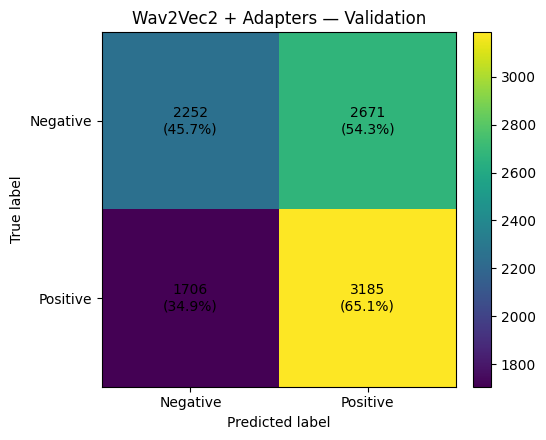

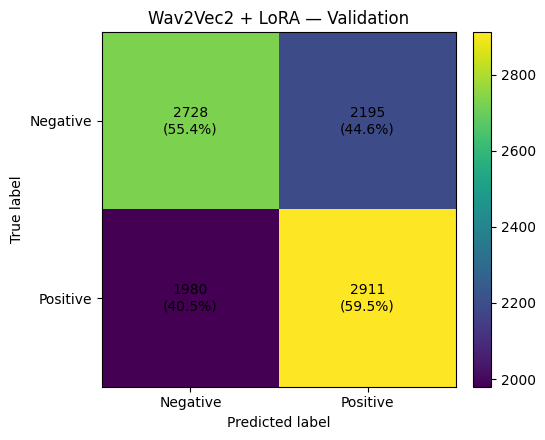

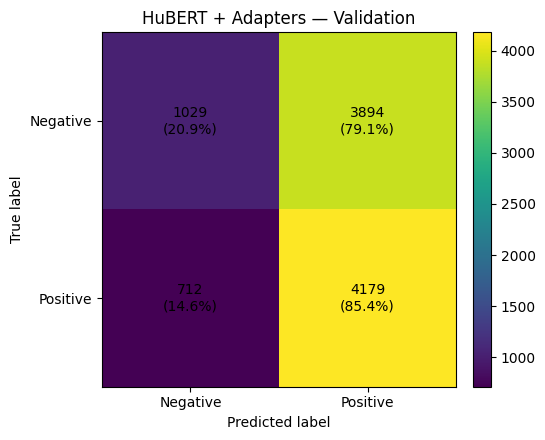

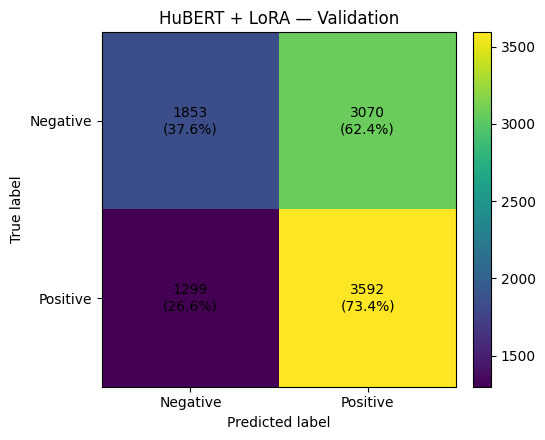

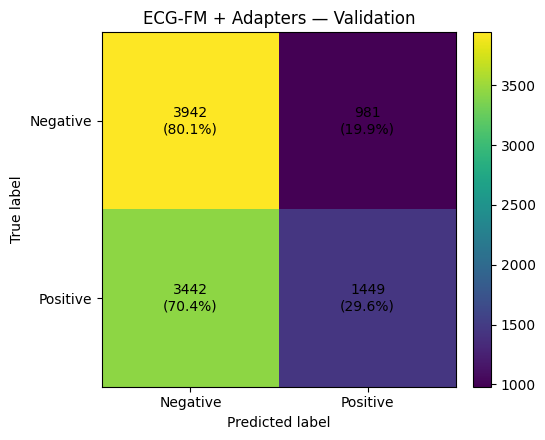

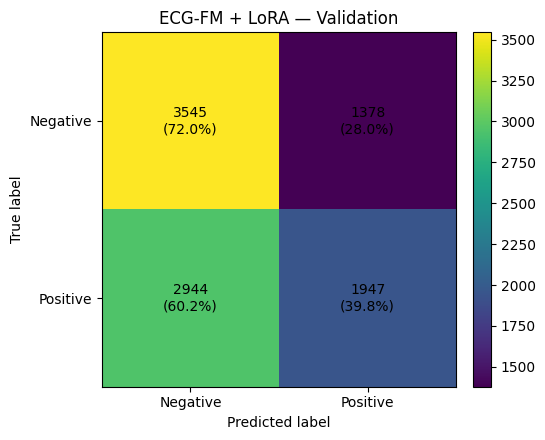

In [124]:
# Confusion matrix plots (matplotlib, no seaborn, one chart per figure)

import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names=("Negative","Positive"), title="Confusion Matrix"):
    cm = np.array(cm, dtype=np.float64)
    # Row-normalized percentages (per true class)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cm_perc = cm / row_sums

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, interpolation='nearest')  # default colormap (no explicit colors)
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")

    # Annotate with counts and row-normalized percentages
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i,
                f"{int(cm[i, j])}\n({cm_perc[i, j]*100:.1f}%)",
                ha="center", va="center", fontsize=10
            )

    fig.tight_layout()
    plt.show()


# Collect available results (Validation split by default)
plots = []

# Create a small helper to add plots only if the variable exists and has a confusion matrix
def add_if_available(var_name, pretty_title):
    g = globals()
    if var_name in g and isinstance(g[var_name], dict) and g[var_name].get("cm") is not None:
        plots.append((g[var_name]["cm"], pretty_title))

# Validation CMs (add as many as exist in your session)
add_if_available("wav_adapters_val", "Wav2Vec2 + Adapters — Validation")
add_if_available("wav_lora_val",     "Wav2Vec2 + LoRA — Validation")
add_if_available("hub_adapters_val", "HuBERT + Adapters — Validation")
add_if_available("hub_lora_val",     "HuBERT + LoRA — Validation")
add_if_available("ecgfm_adapters_val","ECG-FM + Adapters — Validation")
add_if_available("ecgfm_lora_val",    "ECG-FM + LoRA — Validation")

# If no validation results are available, try Test CMs
if not plots:
    add_if_available("wav_adapters_test", "Wav2Vec2 + Adapters — Test")
    add_if_available("wav_lora_test",     "Wav2Vec2 + LoRA — Test")
    add_if_available("hub_adapters_test", "HuBERT + Adapters — Test")
    add_if_available("hub_lora_test",     "HuBERT + LoRA — Test")
    add_if_available("ecgfm_adapters_test","ECG-FM + Adapters — Test")
    add_if_available("ecgfm_lora_test",    "ECG-FM + LoRA — Test")

# Plot whatever is available
if plots:
    for cm, title in plots:
        plot_confusion_matrix(cm, class_names=("Negative","Positive"), title=title)
else:
    print("No confusion matrices found yet. Run the training & evaluation cells first.")
